In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="rOt2vVhbJWVEPYVmNJND")
project = rf.workspace("caretech-v2").project("v2-caretech-combined-dataset")
version = project.version(1)
dataset = version.download("yolo26")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 86.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to V2-CareTech-Combined-Dataset-1 in yolo26:: 100%|██████████| 58568/58568 [00:13<00:00, 4503.68it/s]


In [2]:
import os
import shutil
import random
import math
from collections import defaultdict, Counter

import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Original downloaded dataset from Roboflow
src = "/content/V2-CareTech-Combined-Dataset-1"

# New Run 1 working copy that will overwrite
dst = "/content/run1_balanced_dataset"

print("Original dataset exists:", os.path.exists(src))
print("Existing run1 dataset exists:", os.path.exists(dst))

Original dataset exists: True
Existing run1 dataset exists: False


In [4]:
# Delete the old working copy if it already exists
if os.path.exists(dst):
    shutil.rmtree(dst)
    print("Deleted old run1_balanced_dataset")

# Copy fresh dataset from source
shutil.copytree(src, dst)
print("Created fresh working copy at:", dst)

Created fresh working copy at: /content/run1_balanced_dataset


In [5]:
train_labels_dir = os.path.join(dst, "train", "labels")
train_images_dir = os.path.join(dst, "train", "images")

print("Train labels dir exists:", os.path.exists(train_labels_dir))
print("Train images dir exists:", os.path.exists(train_images_dir))

Train labels dir exists: True
Train images dir exists: True


In [6]:
#class to files map
class_to_files = defaultdict(list)

for label_file in os.listdir(train_labels_dir):
    if not label_file.endswith(".txt"):
        continue

    label_path = os.path.join(train_labels_dir, label_file)

    with open(label_path, "r") as f:
        lines = [line.strip() for line in f if line.strip()]

    if len(lines) == 0:
        continue

    # Your dataset has one class per image
    class_id = int(lines[0].split()[0])
    image_base = os.path.splitext(label_file)[0]

    image_path = None
    for ext in [".jpg", ".jpeg", ".png"]:
        candidate = os.path.join(train_images_dir, image_base + ext)
        if os.path.exists(candidate):
            image_path = candidate
            break

    if image_path is not None:
        class_to_files[class_id].append((image_path, label_path))

print("Mapped classes:", len(class_to_files))

Mapped classes: 216


In [7]:
#check train class counts
print("TRAIN class counts before balancing:\n")

for cls in sorted(class_to_files):
    print(f"Class {cls}: {len(class_to_files[cls])}")

TRAIN class counts before balancing:

Class 0: 79
Class 1: 72
Class 2: 36
Class 3: 69
Class 4: 75
Class 5: 72
Class 6: 74
Class 7: 74
Class 8: 74
Class 9: 73
Class 10: 83
Class 11: 162
Class 12: 174
Class 13: 80
Class 14: 72
Class 15: 71
Class 16: 77
Class 17: 82
Class 18: 79
Class 19: 75
Class 20: 74
Class 21: 73
Class 22: 72
Class 23: 74
Class 24: 78
Class 25: 78
Class 26: 83
Class 27: 71
Class 28: 70
Class 29: 78
Class 30: 70
Class 31: 80
Class 32: 494
Class 33: 76
Class 34: 76
Class 35: 83
Class 36: 70
Class 37: 75
Class 38: 69
Class 39: 80
Class 40: 76
Class 41: 77
Class 42: 79
Class 43: 69
Class 44: 95
Class 45: 85
Class 46: 81
Class 47: 78
Class 48: 68
Class 49: 70
Class 50: 90
Class 51: 77
Class 52: 71
Class 53: 128
Class 54: 79
Class 55: 82
Class 56: 79
Class 57: 70
Class 58: 70
Class 59: 71
Class 60: 236
Class 61: 70
Class 62: 71
Class 63: 239
Class 64: 81
Class 65: 78
Class 66: 265
Class 67: 72
Class 68: 72
Class 69: 70
Class 70: 72
Class 71: 68
Class 72: 83
Class 73: 69
Cla

In [8]:
"""
Run 1 balancing strategy

1. Modify only the train split
2. Leave valid/test unchanged
3. Apply graduated data ablation to the biggest majority classes:
   - 200–299 samples  -> remove 10%
   - 300–399 samples  -> remove 15%
   - 400+ samples     -> remove 20%
4. Lightly upsample the smallest minority classes to 85 samples
5. Use safe augmentations that do not require bounding box changes:
   - bright
   - dark
   - contrast
   - noise
"""

'\nRun 1 balancing strategy\n\n1. Modify only the train split\n2. Leave valid/test unchanged\n3. Apply graduated data ablation to the biggest majority classes:\n   - 200–299 samples  -> remove 10%\n   - 300–399 samples  -> remove 15%\n   - 400+ samples     -> remove 20%\n4. Lightly upsample the smallest minority classes to 85 samples\n5. Use safe augmentations that do not require bounding box changes:\n   - bright\n   - dark\n   - contrast\n   - noise\n'

In [9]:
#majority classes, minority targets
majority_classes = [137, 32, 113, 112, 124, 66, 63, 147, 188, 145, 187, 157]

minority_targets = {
    2: 85,
    125: 85,
    90: 85,
    193: 85,
    148: 85,
    201: 85,
    96: 85,
    78: 85,
    84: 85,
    168: 85,
    210: 85,
}

In [10]:
#apply graduated ablation to majority classes
random.seed(42)

print("Applying graduated ablation to majority classes...\n")

for cls in majority_classes:
    if cls not in class_to_files:
        print(f"Class {cls} not found, skipping")
        continue

    files = class_to_files[cls]
    current_count = len(files)

    if current_count >= 400:
        ablation_pct = 0.20
    elif current_count >= 300:
        ablation_pct = 0.15
    else:
        ablation_pct = 0.10

    remove_count = max(1, math.floor(current_count * ablation_pct))
    target_count = current_count - remove_count

    keep_files = set(random.sample(files, target_count))
    remove_files = [pair for pair in files if pair not in keep_files]

    for image_path, label_path in remove_files:
        if os.path.exists(image_path):
            os.remove(image_path)
        if os.path.exists(label_path):
            os.remove(label_path)

    class_to_files[cls] = list(keep_files)

    print(f"Class {cls}: reduced from {current_count} to {target_count} ({int(ablation_pct * 100)}% ablation)")

Applying graduated ablation to majority classes...

Class 137: reduced from 572 to 458 (20% ablation)
Class 32: reduced from 494 to 396 (20% ablation)
Class 113: reduced from 455 to 364 (20% ablation)
Class 112: reduced from 305 to 260 (15% ablation)
Class 124: reduced from 303 to 258 (15% ablation)
Class 66: reduced from 265 to 239 (10% ablation)
Class 63: reduced from 239 to 216 (10% ablation)
Class 147: reduced from 237 to 214 (10% ablation)
Class 188: reduced from 230 to 207 (10% ablation)
Class 145: reduced from 217 to 196 (10% ablation)
Class 187: reduced from 216 to 195 (10% ablation)
Class 157: reduced from 212 to 191 (10% ablation)


In [11]:
#define safe augmentation function for minor upsampling
def augment_image(img, mode):
    img = img.copy().astype(np.float32)

    if mode == "bright":
        factor = random.uniform(1.10, 1.25)
        img = np.clip(img * factor, 0, 255)

    elif mode == "dark":
        factor = random.uniform(0.75, 0.95)
        img = np.clip(img * factor, 0, 255)

    elif mode == "contrast":
        alpha = random.uniform(0.90, 1.20)
        beta = random.uniform(-8, 8)
        img = np.clip(alpha * img + beta, 0, 255)

    elif mode == "noise":
        noise = np.random.normal(0, 8, img.shape)
        img = np.clip(img + noise, 0, 255)

    return img.astype(np.uint8)

augmentation_modes = ["bright", "dark", "contrast", "noise"]

In [12]:
#preform the upsampling
print("Upsampling minority classes...\n")

for cls, target_count in minority_targets.items():
    if cls not in class_to_files:
        print(f"Class {cls} not found, skipping")
        continue

    # Freeze the original source pool so we do not augment augmented images
    source_files = class_to_files[cls].copy()

    current_count = len(class_to_files[cls])
    needed = target_count - current_count

    if needed <= 0:
        print(f"Class {cls}: already at or above target ({current_count}), skipping")
        continue

    created = 0
    attempt = 0

    while created < needed and attempt < needed * 20:
        attempt += 1

        image_path, label_path = random.choice(source_files)
        img = cv2.imread(image_path)

        if img is None:
            continue

        mode = random.choice(augmentation_modes)
        aug_img = augment_image(img, mode)

        base_name = os.path.splitext(os.path.basename(image_path))[0]
        ext = os.path.splitext(image_path)[1]

        new_base = f"{base_name}_aug_{mode}_{created}"
        new_image_path = os.path.join(train_images_dir, new_base + ext)
        new_label_path = os.path.join(train_labels_dir, new_base + ".txt")

        if os.path.exists(new_image_path) or os.path.exists(new_label_path):
            continue

        cv2.imwrite(new_image_path, aug_img)
        shutil.copy(label_path, new_label_path)

        class_to_files[cls].append((new_image_path, new_label_path))
        created += 1

    print(f"Class {cls}: increased from {current_count} to {current_count + created}")

Upsampling minority classes...

Class 2: increased from 36 to 85
Class 125: increased from 39 to 85
Class 90: increased from 60 to 85
Class 193: increased from 60 to 85
Class 148: increased from 60 to 85
Class 201: increased from 62 to 85
Class 96: increased from 63 to 85
Class 78: increased from 65 to 85
Class 84: increased from 65 to 85
Class 168: increased from 65 to 85
Class 210: increased from 65 to 85


In [13]:
#check new counts
new_counts = Counter()

for label_file in os.listdir(train_labels_dir):
    if not label_file.endswith(".txt"):
        continue

    label_path = os.path.join(train_labels_dir, label_file)
    with open(label_path, "r") as f:
        line = f.readline().strip()
        if line:
            cls = int(line.split()[0])
            new_counts[cls] += 1

print("NEW TRAIN class counts after balancing:\n")
for cls in sorted(new_counts):
    print(f"Class {cls}: {new_counts[cls]}")

NEW TRAIN class counts after balancing:

Class 0: 79
Class 1: 72
Class 2: 85
Class 3: 69
Class 4: 75
Class 5: 72
Class 6: 74
Class 7: 74
Class 8: 74
Class 9: 73
Class 10: 83
Class 11: 162
Class 12: 174
Class 13: 80
Class 14: 72
Class 15: 71
Class 16: 77
Class 17: 82
Class 18: 79
Class 19: 75
Class 20: 74
Class 21: 73
Class 22: 72
Class 23: 74
Class 24: 78
Class 25: 78
Class 26: 83
Class 27: 71
Class 28: 70
Class 29: 78
Class 30: 70
Class 31: 80
Class 32: 396
Class 33: 76
Class 34: 76
Class 35: 83
Class 36: 70
Class 37: 75
Class 38: 69
Class 39: 80
Class 40: 76
Class 41: 77
Class 42: 79
Class 43: 69
Class 44: 95
Class 45: 85
Class 46: 81
Class 47: 78
Class 48: 68
Class 49: 70
Class 50: 90
Class 51: 77
Class 52: 71
Class 53: 128
Class 54: 79
Class 55: 82
Class 56: 79
Class 57: 70
Class 58: 70
Class 59: 71
Class 60: 236
Class 61: 70
Class 62: 71
Class 63: 216
Class 64: 81
Class 65: 78
Class 66: 239
Class 67: 72
Class 68: 72
Class 69: 70
Class 70: 72
Class 71: 68
Class 72: 83
Class 73: 69


In [14]:
train_image_files = [f for f in os.listdir(train_images_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
train_label_files = [f for f in os.listdir(train_labels_dir) if f.endswith(".txt")]

print("Train images:", len(train_image_files))
print("Train labels:", len(train_label_files))
print("Counts match:", len(train_image_files) == len(train_label_files))

Train images: 20252
Train labels: 20252
Counts match: True


In [15]:
aug_examples = [f for f in train_image_files if "_aug_" in f][:20]

print("Sample augmented files:")
for f in aug_examples:
    print(f)

Sample augmented files:
yusuf_6e9f89a2758892d3_jpg.rf.adf63fa595b07033c6dcc482fae7a5f6_aug_dark_40.jpg
japanese_tofu_and_vegetable_chowder_012147_jpg.rf.3c07255a07cc81bb2a0ec060958e85a5_aug_dark_5.jpg
shrimp_patties_204392_jpg.rf.f8023c345b9ce5d456c670a383035f01_aug_contrast_19.jpg
gulai_233026_jpg.rf.573c810dad31cbd194d7e2d0b9f3895e_aug_bright_10.jpg
teriyaki_grilled_fish_004389_jpg.rf.46f567000d5f56a5d10ab2a4e404f2dd_aug_contrast_14.jpg
gulai_232938_jpg.rf.5f9ab896d04f7aecc8fedade46208c1b_aug_dark_11.jpg
rice_ball_012505_jpg.rf.62d3532103955ee7f1bf37a2fd586ffb_aug_bright_6.jpg
yusuf_22cf78f0eb8e7f25_jpg.rf.f7cda18175c35d2b2a6c3ead0ae89514_aug_dark_34.jpg
yusuf_db1af159a2c0fef4_jpg.rf.b0d23ccf35712b101c4d8786c889dacb_aug_noise_14.jpg
yusuf_500ef7bbed25b42d_jpg.rf.6ae2861954c4b6cb17c91e1948586662_aug_noise_33.jpg
yusuf_7e6a885c298febf5_jpg.rf.aa49a2df0e2ecc2d78e1f33a11459dd7_aug_dark_13.jpg
vermicelli_noodles_with_snails_202914_jpg.rf.7b11f52decd68b4789ae3e28d2c211ba_aug_bright_18.jpg


In [16]:
from collections import Counter
import os

new_counts = Counter()

for label_file in os.listdir(train_labels_dir):
    if not label_file.endswith(".txt"):
        continue

    label_path = os.path.join(train_labels_dir, label_file)
    with open(label_path, "r") as f:
        line = f.readline().strip()
        if line:
            cls = int(line.split()[0])
            new_counts[cls] += 1

print("NEW TRAIN class counts after balancing:\n")
for cls in sorted(new_counts):
    print(f"Class {cls}: {new_counts[cls]}")

NEW TRAIN class counts after balancing:

Class 0: 79
Class 1: 72
Class 2: 85
Class 3: 69
Class 4: 75
Class 5: 72
Class 6: 74
Class 7: 74
Class 8: 74
Class 9: 73
Class 10: 83
Class 11: 162
Class 12: 174
Class 13: 80
Class 14: 72
Class 15: 71
Class 16: 77
Class 17: 82
Class 18: 79
Class 19: 75
Class 20: 74
Class 21: 73
Class 22: 72
Class 23: 74
Class 24: 78
Class 25: 78
Class 26: 83
Class 27: 71
Class 28: 70
Class 29: 78
Class 30: 70
Class 31: 80
Class 32: 396
Class 33: 76
Class 34: 76
Class 35: 83
Class 36: 70
Class 37: 75
Class 38: 69
Class 39: 80
Class 40: 76
Class 41: 77
Class 42: 79
Class 43: 69
Class 44: 95
Class 45: 85
Class 46: 81
Class 47: 78
Class 48: 68
Class 49: 70
Class 50: 90
Class 51: 77
Class 52: 71
Class 53: 128
Class 54: 79
Class 55: 82
Class 56: 79
Class 57: 70
Class 58: 70
Class 59: 71
Class 60: 236
Class 61: 70
Class 62: 71
Class 63: 216
Class 64: 81
Class 65: 78
Class 66: 239
Class 67: 72
Class 68: 72
Class 69: 70
Class 70: 72
Class 71: 68
Class 72: 83
Class 73: 69


In [17]:
before_counts = {
    2: 36,
    32: 494,
    63: 239,
    66: 265,
    78: 65,
    84: 65,
    90: 60,
    96: 63,
    112: 305,
    113: 455,
    124: 303,
    125: 39,
    137: 572,
    145: 217,
    147: 237,
    148: 60,
    157: 212,
    168: 65,
    187: 216,
    188: 230,
    193: 60,
    201: 62,
    210: 65,
}

changed_classes = sorted(before_counts.keys())

print("Before vs After for modified classes:\n")
for cls in changed_classes:
    before_val = before_counts[cls]
    after_val = new_counts.get(cls, 0)
    print(f"Class {cls}: {before_val} -> {after_val}")

Before vs After for modified classes:

Class 2: 36 -> 85
Class 32: 494 -> 396
Class 63: 239 -> 216
Class 66: 265 -> 239
Class 78: 65 -> 85
Class 84: 65 -> 85
Class 90: 60 -> 85
Class 96: 63 -> 85
Class 112: 305 -> 260
Class 113: 455 -> 364
Class 124: 303 -> 258
Class 125: 39 -> 85
Class 137: 572 -> 458
Class 145: 217 -> 196
Class 147: 237 -> 214
Class 148: 60 -> 85
Class 157: 212 -> 191
Class 168: 65 -> 85
Class 187: 216 -> 195
Class 188: 230 -> 207
Class 193: 60 -> 85
Class 201: 62 -> 85
Class 210: 65 -> 85


In [18]:
minority_targets = {
    2: 85,
    125: 85,
    90: 85,
    193: 85,
    148: 85,
    201: 85,
    96: 85,
    78: 85,
    84: 85,
    168: 85,
    210: 85,
}

print("Minority target check:\n")
for cls, target in minority_targets.items():
    actual = new_counts.get(cls, 0)
    status = "OK" if actual >= target else "LOW"
    print(f"Class {cls}: target={target}, actual={actual} -> {status}")

Minority target check:

Class 2: target=85, actual=85 -> OK
Class 125: target=85, actual=85 -> OK
Class 90: target=85, actual=85 -> OK
Class 193: target=85, actual=85 -> OK
Class 148: target=85, actual=85 -> OK
Class 201: target=85, actual=85 -> OK
Class 96: target=85, actual=85 -> OK
Class 78: target=85, actual=85 -> OK
Class 84: target=85, actual=85 -> OK
Class 168: target=85, actual=85 -> OK
Class 210: target=85, actual=85 -> OK


In [ ]:
import shutil

zip_path = shutil.make_archive("/content/run1_balanced_dataset_fixed", "zip", dst)

print(zip_path)

/content/run1_balanced_dataset_fixed.zip


In [ ]:
from google.colab import files
files.download("/content/run1_balanced_dataset_fixed.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install -q roboflow

In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="lO7jC3tLYgYVRDJ0wcVn")

In [ ]:
workspace = rf.workspace("jacobs-workspace-dy0ed")
print(workspace)

loading Roboflow workspace...
{
  "name": "Jacobs Workspace",
  "url": "jacobs-workspace-dy0ed",
  "projects": [
    "jacobs-workspace-dy0ed/jh-run1-balacing"
  ]
}


In [ ]:
project = workspace.project("jh-run1-balacing")
print(project)

loading Roboflow project...
{
  "name": "jh-run1-balacing",
  "type": "object-detection",
  "workspace": "jacobs-workspace-dy0ed"
}


In [ ]:
import os

dataset_path = "/content/run1_balanced_dataset"

print("Dataset exists:", os.path.exists(dataset_path))
print("Top-level contents:", os.listdir(dataset_path))

Dataset exists: True
Top-level contents: ['valid', 'data.yaml', 'README.dataset.txt', 'README.roboflow.txt', 'test', 'train']


In [ ]:
for split in ["train", "valid", "test"]:
    img_dir = os.path.join(dataset_path, split, "images")
    lbl_dir = os.path.join(dataset_path, split, "labels")

    img_count = len([f for f in os.listdir(img_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
    lbl_count = len([f for f in os.listdir(lbl_dir) if f.endswith(".txt")])

    print(split)
    print(" images:", img_count)
    print(" labels:", lbl_count)
    print()

train
 images: 20252
 labels: 20252

valid
 images: 5821
 labels: 5821

test
 images: 2949
 labels: 2949



In [ ]:
%cd /content/run1_balanced_dataset
!zip -rq /content/run1_dataset_for_roboflow.zip train valid test data.yaml
print("Created /content/run1_dataset_for_roboflow.zip")

/content/run1_balanced_dataset
Created /content/run1_dataset_for_roboflow.zip


In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="lO7jC3tLYgYVRDJ0wcVn")

In [ ]:
workspace = rf.workspace("jacobs-workspace-dy0ed")
print(workspace)

loading Roboflow workspace...
{
  "name": "Jacobs Workspace",
  "url": "jacobs-workspace-dy0ed",
  "projects": [
    "jacobs-workspace-dy0ed/jh-run1-balacing"
  ]
}


In [ ]:
workspace.upload_dataset(
    "/content/run1_balanced_dataset",
    "jh-run1-balacing",
    num_workers=10,
    project_license="MIT",
    project_type="object-detection"
)

Streaming output truncated to the last 5000 lines.
[UPLOADED] /content/run1_balanced_dataset/valid/images/chow_mein_325984_jpg.rf.ef15b1135ddde42387d739a2e119eece.jpg (h0Fyd8kszr6OpnN8KtqB) [0.4s] / annotations = OK [0.5s]
[UPLOADED] /content/run1_balanced_dataset/valid/images/chow_mein_325254_jpg.rf.3451204921f3d6aa797923a4a9967321.jpg (NtGekagxDp5C9GfWSH33) [1.0s] / annotations = OK [0.5s]
[UPLOADED] /content/run1_balanced_dataset/valid/images/chow_mein_326732_jpg.rf.6987c2cb79183335f9408471077ca2cb.jpg (RqvXAk5oXx6Ru7146fcX) [0.6s] / annotations = OK [0.3s]
[UPLOADED] /content/run1_balanced_dataset/valid/images/chow_mein_325970_jpg.rf.197ec600b3dea464a82421ef3d6c4168.jpg (T3jdypYfn3R1ZEkpf8ah) [0.5s] / annotations = OK [0.7s]
[UPLOADED] /content/run1_balanced_dataset/valid/images/chow_mein_327316_jpg.rf.87328eee439ffee2f18951b51d10e3e4.jpg (sPetTGtpy1oJEaPKi54D) [0.5s] / annotations = OK [0.3s]
[UPLOADED] /content/run1_balanced_dataset/valid/images/chow_mein_326881_jpg.rf.8a5a332743

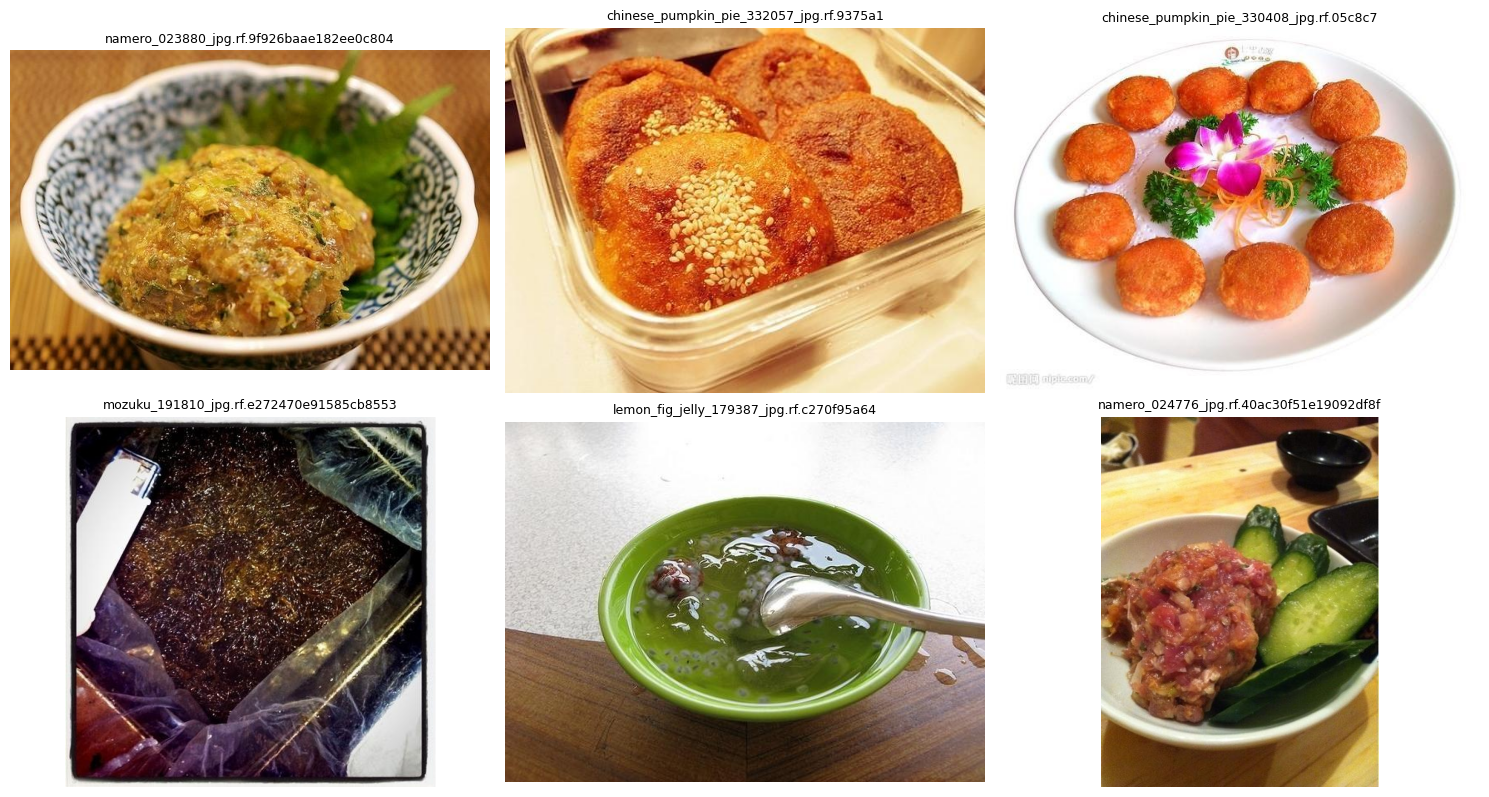

In [19]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

DATASET_ROOT = "/content/run1_balanced_dataset"

def show_empty_label_images(split="train", n=6):
    label_dir = os.path.join(DATASET_ROOT, split, "labels")
    image_dir = os.path.join(DATASET_ROOT, split, "images")

    empty_files = []
    for fname in os.listdir(label_dir):
        if not fname.endswith(".txt"):
            continue
        path = os.path.join(label_dir, fname)
        with open(path, "r") as f:
            lines = [line.strip() for line in f if line.strip()]
        if not lines:
            empty_files.append(fname)

    samples = random.sample(empty_files, min(n, len(empty_files)))

    plt.figure(figsize=(15, 8))
    for i, fname in enumerate(samples, 1):
        base = fname.replace(".txt", "")
        img_path = None
        for ext in [".jpg", ".jpeg", ".png", ".webp"]:
            candidate = os.path.join(image_dir, base + ext)
            if os.path.exists(candidate):
                img_path = candidate
                break

        if img_path is None:
            # handle filenames like xxx_jpg.rf.... -> actual image already has .jpg in base
            for file in os.listdir(image_dir):
                if file.startswith(base):
                    img_path = os.path.join(image_dir, file)
                    break

        if img_path:
            img = Image.open(img_path).convert("RGB")
            plt.subplot(2, 3, i)
            plt.imshow(img)
            plt.title(fname[:40], fontsize=9)
            plt.axis("off")

    plt.tight_layout()
    plt.show()

show_empty_label_images("train", n=6)

In [20]:
import os
from collections import defaultdict, Counter

ORIG_ROOT = "/content/V2-CareTech-Combined-Dataset-1"
BAL_ROOT  = "/content/run1_balanced_dataset"

def normalize_name(fname):
    # remove roboflow hash
    if ".rf." in fname:
        fname = fname.split(".rf.")[0] + ".txt"
    return fname

def load_labels_anysplit(root):
    data = {}
    for split in ["train", "valid", "test"]:
        label_dir = os.path.join(root, split, "labels")
        if not os.path.exists(label_dir):
            continue

        for f in os.listdir(label_dir):
            if not f.endswith(".txt"):
                continue

            norm = normalize_name(f)
            path = os.path.join(label_dir, f)

            with open(path) as file:
                content = file.read().strip()

            data[norm] = {
                "empty": content == "",
                "raw": f,
                "split": split
            }

    return data


orig = load_labels_anysplit(ORIG_ROOT)
bal  = load_labels_anysplit(BAL_ROOT)

summary = Counter()

examples = defaultdict(list)

for name, bal_info in bal.items():

    if name not in orig:
        summary["not_in_original"] += 1
        if len(examples["not_in_original"]) < 10:
            examples["not_in_original"].append(name)
        continue

    orig_empty = orig[name]["empty"]
    bal_empty  = bal_info["empty"]

    if orig_empty and bal_empty:
        summary["empty_in_both"] += 1

    elif (not orig_empty) and bal_empty:
        summary["became_empty_after_balancing"] += 1
        if len(examples["became_empty_after_balancing"]) < 10:
            examples["became_empty_after_balancing"].append(name)

    else:
        summary["ok"] += 1


print("SUMMARY")
for k,v in summary.items():
    print(k,":",v)

print("\nExamples of label loss:")
for x in examples["became_empty_after_balancing"]:
    print(x)

SUMMARY
ok : 27840
empty_in_both : 887

Examples of label loss:


In [21]:
import os

DATASET_ROOT = "/content/run1_balanced_dataset"

removed = 0

for split in ["train","valid","test"]:
    label_dir = os.path.join(DATASET_ROOT, split, "labels")
    image_dir = os.path.join(DATASET_ROOT, split, "images")

    for fname in os.listdir(label_dir):
        path = os.path.join(label_dir, fname)

        with open(path) as f:
            content = f.read().strip()

        if content == "":
            os.remove(path)

            base = fname.replace(".txt","")
            for img in os.listdir(image_dir):
                if img.startswith(base):
                    os.remove(os.path.join(image_dir,img))
                    break

            removed += 1

print("Removed:", removed)

Removed: 887


In [22]:
import os

DATASET_ROOT = "/content/run1_balanced_dataset"

for split in ["train", "valid", "test"]:
    image_dir = os.path.join(DATASET_ROOT, split, "images")
    label_dir = os.path.join(DATASET_ROOT, split, "labels")

    images = len([f for f in os.listdir(image_dir) if not f.startswith(".")])
    labels = len([f for f in os.listdir(label_dir) if not f.startswith(".")])

    print(f"{split.upper()}: images={images}, labels={labels}, match={images == labels}")

TRAIN: images=19640, labels=19640, match=True
VALID: images=5636, labels=5636, match=True
TEST: images=2859, labels=2859, match=True


In [24]:
import os
import yaml

DATASET_ROOT = "/content/run1_balanced_dataset"
TARGET_CLASS_NAME = "meat-loaf"   # change if needed

# ----------------------------
# load class names from data.yaml
# ----------------------------
yaml_path = os.path.join(DATASET_ROOT, "data.yaml")
with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

names = data["names"]
if isinstance(names, dict):
    class_names = [names[i] for i in range(len(names))]
else:
    class_names = list(names)

if TARGET_CLASS_NAME not in class_names:
    raise ValueError(f"Class '{TARGET_CLASS_NAME}' not found in data.yaml")

target_id = class_names.index(TARGET_CLASS_NAME)
print("Removing class:", TARGET_CLASS_NAME, "| class_id:", target_id)

# new class list without target
new_class_names = [name for i, name in enumerate(class_names) if i != target_id]

# remap old ids -> new ids
id_map = {}
new_id = 0
for old_id in range(len(class_names)):
    if old_id == target_id:
        continue
    id_map[old_id] = new_id
    new_id += 1

removed_images = 0
updated_labels = 0
removed_annotations = 0

# ----------------------------
# process each split
# ----------------------------
for split in ["train", "valid", "test"]:
    label_dir = os.path.join(DATASET_ROOT, split, "labels")
    image_dir = os.path.join(DATASET_ROOT, split, "images")

    for fname in os.listdir(label_dir):
        if not fname.endswith(".txt"):
            continue

        label_path = os.path.join(label_dir, fname)

        with open(label_path, "r") as f:
            lines = [line.strip() for line in f if line.strip()]

        if not lines:
            continue

        new_lines = []

        for line in lines:
            parts = line.split()
            old_cls = int(parts[0])

            if old_cls == target_id:
                removed_annotations += 1
                continue

            # remap surviving class ids
            parts[0] = str(id_map[old_cls])
            new_lines.append(" ".join(parts))

        if len(new_lines) == 0:
            # remove empty label file and matching image
            os.remove(label_path)

            base = fname[:-4]  # remove .txt
            found_img = False
            for img_name in os.listdir(image_dir):
                if img_name.startswith(base):
                    os.remove(os.path.join(image_dir, img_name))
                    found_img = True
                    break

            removed_images += 1
        else:
            with open(label_path, "w") as f:
                f.write("\n".join(new_lines) + "\n")
            updated_labels += 1

# ----------------------------
# update data.yaml
# ----------------------------
data["names"] = new_class_names
data["nc"] = len(new_class_names)

with open(yaml_path, "w") as f:
    yaml.safe_dump(data, f, sort_keys=False)

print("\nDone.")
print("Removed annotations:", removed_annotations)
print("Removed images that became empty:", removed_images)
print("Updated label files:", updated_labels)
print("New class count:", len(new_class_names))

Removing class: meat-loaf | class_id: 108

Done.
Removed annotations: 113
Removed images that became empty: 113
Updated label files: 28022
New class count: 215


In [26]:
import os

DATASET_ROOT = "/content/run1_balanced_dataset"

empty_count = 0

for split in ["train", "valid", "test"]:
    label_dir = os.path.join(DATASET_ROOT, split, "labels")

    for fname in os.listdir(label_dir):
        if not fname.endswith(".txt"):
            continue
        path = os.path.join(label_dir, fname)
        with open(path, "r") as f:
            content = f.read().strip()
        if content == "":
            empty_count += 1
            print("Empty label still found:", split, fname)

print("Total empty labels left:", empty_count)

Total empty labels left: 0


In [27]:
import os
import yaml
from collections import Counter, defaultdict

DATASET_ROOT = "/content/run1_balanced_dataset"

yaml_path = os.path.join(DATASET_ROOT, "data.yaml")
with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

names = data["names"]
if isinstance(names, dict):
    class_map = {int(k): v for k, v in names.items()}
else:
    class_map = {i: name for i, name in enumerate(names)}

train_counts = Counter()
train_images_per_class = defaultdict(set)

label_dir = os.path.join(DATASET_ROOT, "train", "labels")
for fname in os.listdir(label_dir):
    if not fname.endswith(".txt"):
        continue
    path = os.path.join(label_dir, fname)
    with open(path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                cls_id = int(parts[0])
                train_counts[cls_id] += 1
                train_images_per_class[cls_id].add(fname)

print("Smallest 15 train classes:")
for cls_id, cnt in sorted(train_counts.items(), key=lambda x: x[1])[:15]:
    print(
        f"ID {cls_id:3d} | {class_map.get(cls_id, 'UNKNOWN'):35s} | "
        f"objects={cnt:4d} | images={len(train_images_per_class[cls_id]):4d}"
    )

Smallest 15 train classes:
ID 102 | lightly-roasted-fish                | objects=  67 | images=  67
ID 105 | macaroni-salad                      | objects=  68 | images=  68
ID 133 | pizza-toast                         | objects=  68 | images=  68
ID  48 | dried-fish                          | objects=  68 | images=  68
ID 119 | noodles-with-fish-curry             | objects=  68 | images=  68
ID  71 | goya-chanpuru                       | objects=  68 | images=  68
ID  73 | green-curry                         | objects=  69 | images=  69
ID  38 | crispy-noodles                      | objects=  69 | images=  69
ID  43 | custard-tart                        | objects=  69 | images=  69
ID 162 | sauteed-spinach                     | objects=  69 | images=  69
ID 165 | scrambled-egg                       | objects=  69 | images=  69
ID 170 | small-steamed-savory-rice-pancake   | objects=  69 | images=  69
ID   3 | apple-pie                           | objects=  69 | images=  69
ID 185 | st

In [29]:
%cd /content/run1_balanced_dataset
!zip -rq /content/run1_dataset_for_roboflow_2.zip train valid test data.yaml
print("Created /content/run1_dataset_for_roboflow_2.zip")

/content/run1_balanced_dataset
Created /content/run1_dataset_for_roboflow_2.zip


In [28]:
from roboflow import Roboflow

rf = Roboflow(api_key="esqnOgC4L5hxz1skFPmo")

In [30]:
workspace = rf.workspace("jacobs-workspace-pktzh")
print(workspace)

loading Roboflow workspace...
{
  "name": "Jacobs Workspace",
  "url": "jacobs-workspace-pktzh",
  "projects": [
    "jacobs-workspace-pktzh/jh-r3-caretech"
  ]
}


In [32]:
workspace.upload_dataset(
    "/content/run1_balanced_dataset",
    "jh-r3-caretech",
    num_workers=10,
    project_license="MIT",
    project_type="object-detection"
)

Streaming output truncated to the last 5000 lines.
[UPLOADED] /content/run1_balanced_dataset/valid/images/chicken-n-egg_on_rice_000318_jpg.rf.37af3c3724663a6e4c6bbab3b7465cd9.jpg (oDyWpgYOpgpAbZhTfg4O) [0.5s] / annotations = OK [0.4s]
[UPLOADED] /content/run1_balanced_dataset/valid/images/charcoal-boiled_pork_neck_311215_jpg.rf.02cd2edb10856c74f1a3422cbacf3beb.jpg (vD9MJy6HbmzuTPTJUioG) [0.8s] / annotations = OK [0.7s]
[UPLOADED] /content/run1_balanced_dataset/valid/images/chicken-n-egg_on_rice_000326_jpg.rf.b943bda2facd78305f4a61dcd618e8eb.jpg (oyBCbrgup8YzHApoO9S1) [0.5s] / annotations = OK [0.4s]
[UPLOADED] /content/run1_balanced_dataset/valid/images/chicken-n-egg_on_rice_000311_jpg.rf.51f48ede9f3b07b66b978a3e8fd37792.jpg (o03v3IVt057GPkb4Swg6) [0.5s] / annotations = OK [0.7s]
[UPLOADED] /content/run1_balanced_dataset/valid/images/chicken-n-egg_on_rice_000386_jpg.rf.a59d808983326c81fb658460ede730bd.jpg (UdaGFoE9vfcc5IL1T95v) [0.5s] / annotations = OK [0.5s]
[UPLOADED] /content/run1_